<a href="https://colab.research.google.com/github/rc2308/churn-ensemble-engine/blob/main/notebooks/05_shap_explainability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 05 — SHAP Explainability

**Goal:** Explain churn predictions globally and per-persona using SHAP.
Reveals which features drive churn and how drivers differ across segments.

**Uses:** `src/explain.py` + all other modules


In [1]:
import os
os.chdir("/content")
!rm -rf churn-ensemble-engine
!git clone https://github.com/rc2308/churn-ensemble-engine.git
%cd churn-ensemble-engine
!pip install -q -r requirements.txt


Cloning into 'churn-ensemble-engine'...
remote: Enumerating objects: 63, done.
remote: Counting objects: 100% (63/63), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 63 (delta 29), reused 31 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (63/63), 688.21 KiB | 15.64 MiB/s, done.
Resolving deltas: 100% (29/29), done.
/content/churn-ensemble-engine
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 74.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 84.0 MB/s eta 0:00:00


In [2]:
from google.colab import files
uploaded = files.upload()   # select BankChurners.csv


Saving BankChurners.csv to BankChurners.csv


In [5]:
import pandas as pd
import numpy as np

from src.data_prep import load_data, clean_data, split_data
from src.features import engineer_features, encode_categoricals, scale_for_clustering
from src.clustering import fit_kmeans, assign_clusters
from src.models import train_xgb

# Pipeline
df = load_data("BankChurners.csv")
df = clean_data(df)
df = engineer_features(df)
df_encoded = encode_categoricals(df)

# Clusters
clust_feats = [
    "Customer_Age", "Credit_Limit", "Total_Trans_Ct", "Total_Trans_Amt",
    "Avg_Utilization_Ratio", "Months_Inactive_12_mon",
    "Total_Relationship_Count", "Amt_per_Transaction"
]
scaled, scaler = scale_for_clustering(df_encoded, clust_feats)
km = fit_kmeans(scaled, k=4)
df_encoded["Cluster"] = assign_clusters(km, scaled)

# Split + train (we explain the model)
X_train, X_test, y_train, y_test = split_data(df_encoded, target_col="Churn")
xgb = train_xgb(X_train, y_train)

print("Setup complete ")


Setup complete 


In [4]:
import os
os.makedirs("reports/shap_plots", exist_ok=True)
print("SHAP folder ready")


SHAP folder ready


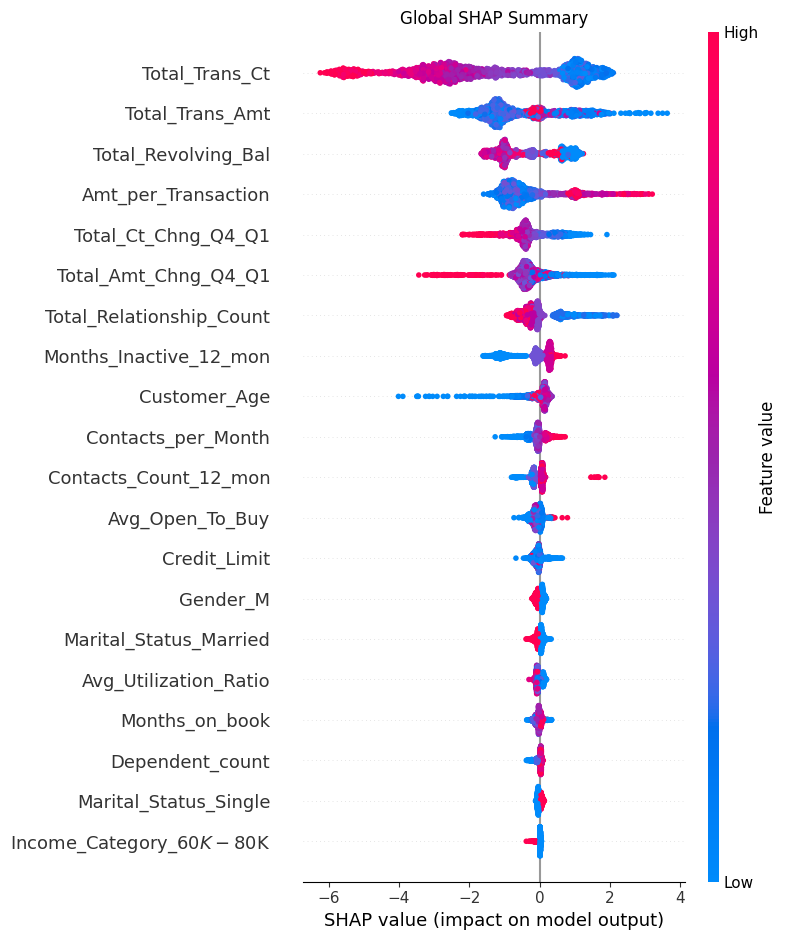

Top 10 global churn drivers:


,0
Total_Trans_Ct,2.217668
Total_Trans_Amt,1.088819
Total_Revolving_Bal,0.864298
Amt_per_Transaction,0.777460
Total_Ct_Chng_Q4_Q1,0.534552
Total_Amt_Chng_Q4_Q1,0.503826
Total_Relationship_Count,0.434635
Months_Inactive_12_mon,0.402110
Customer_Age,0.230109
Contacts_per_Month,0.175771


In [6]:
from src.explain import global_shap

importance = global_shap(
    xgb, X_test,
    save_path="reports/shap_plots/global_shap.png"
)

print("Top 10 global churn drivers:")
importance.head(10)


In [7]:
# Cluster label is already a column in X_test (we added it before split)
test_clusters = X_test["Cluster"].values

print("Cluster distribution in test set:")
print(pd.Series(test_clusters).value_counts().sort_index())


Cluster distribution in test set:
0    651
1    272
2    853
3    250
Name: count, dtype: int64



Cluster 0: Loyal Revolvers


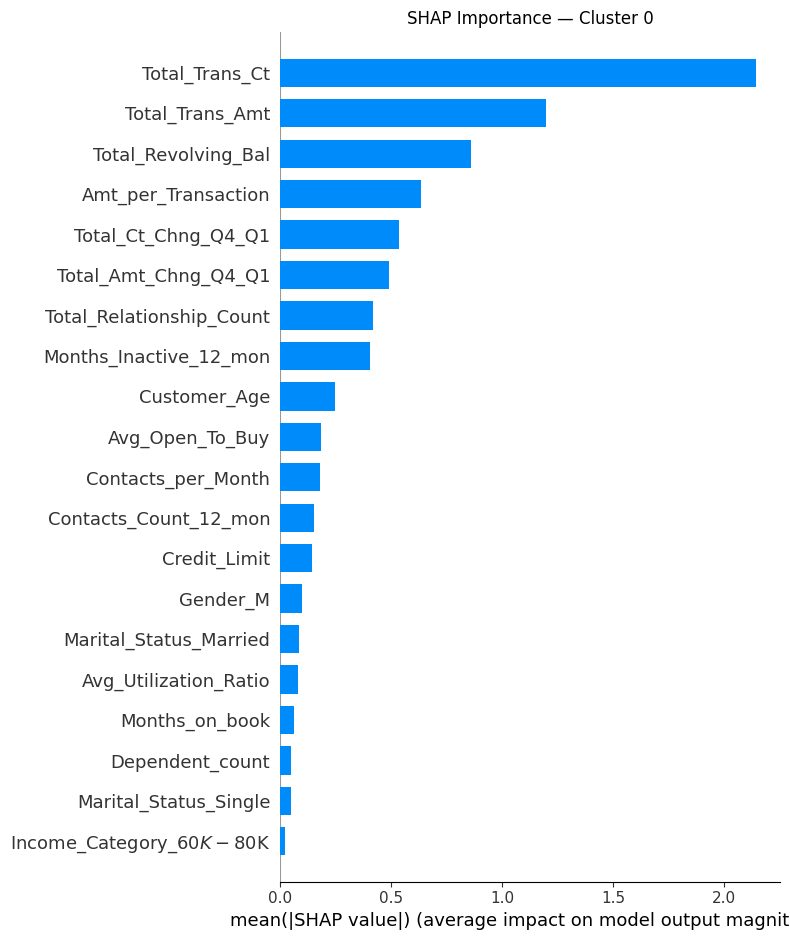

Total_Trans_Ct              2.143315
Total_Trans_Amt             1.199479
Total_Revolving_Bal         0.858044
Amt_per_Transaction         0.633597
Total_Ct_Chng_Q4_Q1         0.536106
Total_Amt_Chng_Q4_Q1        0.490810
Total_Relationship_Count    0.417736
Months_Inactive_12_mon      0.404354
dtype: float32

Cluster 1: High-Value Spenders


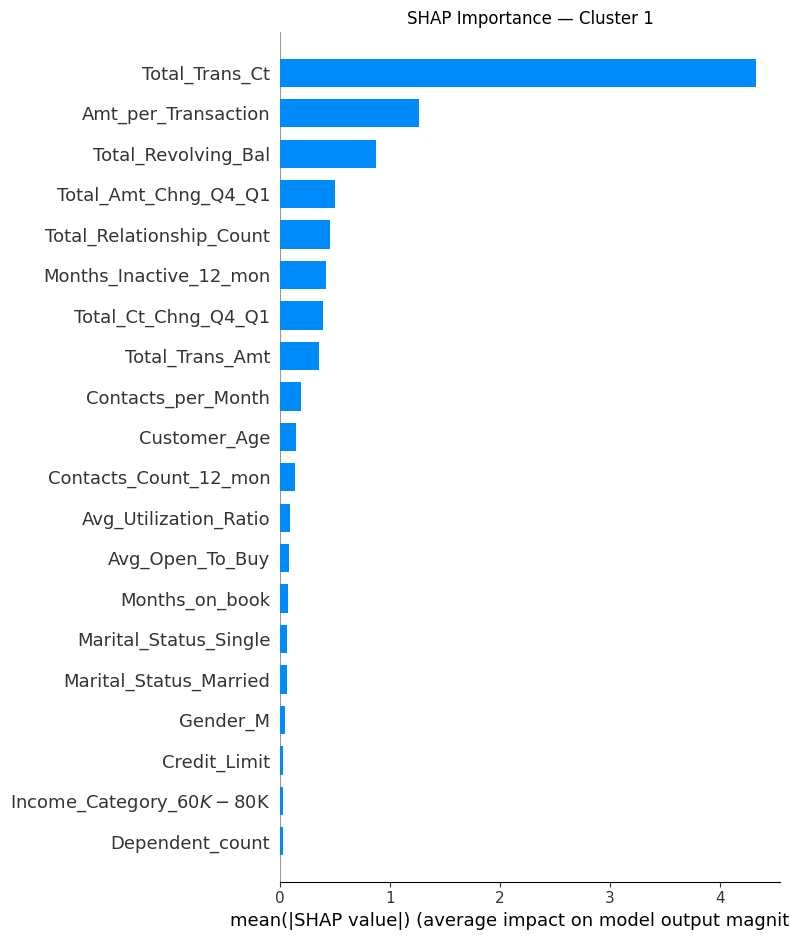

Total_Trans_Ct              4.328561
Amt_per_Transaction         1.265420
Total_Revolving_Bal         0.869434
Total_Amt_Chng_Q4_Q1        0.499732
Total_Relationship_Count    0.450283
Months_Inactive_12_mon      0.419233
Total_Ct_Chng_Q4_Q1         0.392345
Total_Trans_Amt             0.359208
dtype: float32

Cluster 2: At-Risk Average Users


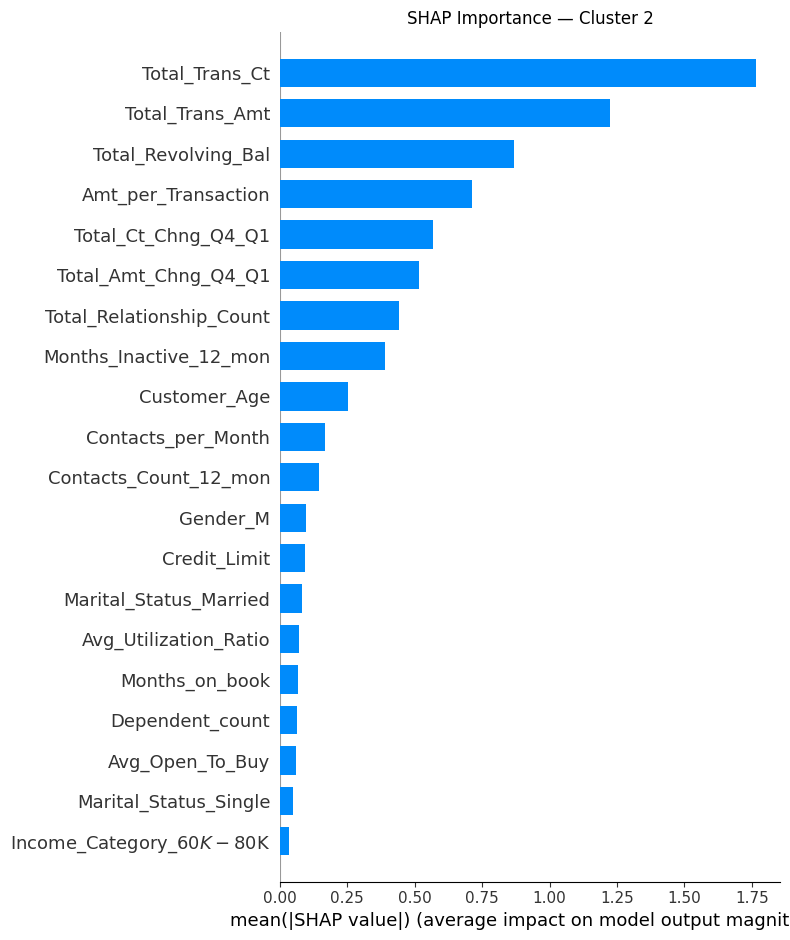

Total_Trans_Ct              1.766502
Total_Trans_Amt             1.223459
Total_Revolving_Bal         0.868833
Amt_per_Transaction         0.712001
Total_Ct_Chng_Q4_Q1         0.567587
Total_Amt_Chng_Q4_Q1        0.515085
Total_Relationship_Count    0.440706
Months_Inactive_12_mon      0.390915
dtype: float32

Cluster 3: Dormant High-Limit


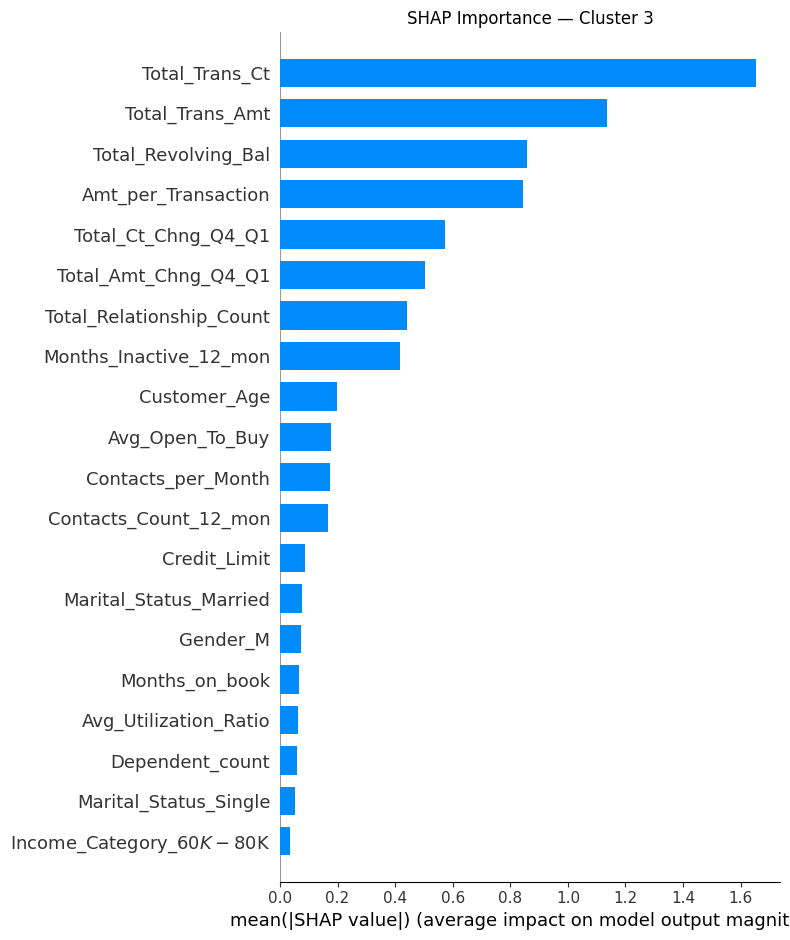

Total_Trans_Ct              1.654042
Total_Trans_Amt             1.135074
Total_Revolving_Bal         0.859526
Amt_per_Transaction         0.844526
Total_Ct_Chng_Q4_Q1         0.572511
Total_Amt_Chng_Q4_Q1        0.503756
Total_Relationship_Count    0.440903
Months_Inactive_12_mon      0.415835
dtype: float32


In [9]:
from src.explain import per_cluster_shap

persona_names = {
    0: "Loyal Revolvers",
    1: "High-Value Spenders",
    2: "At-Risk Average Users",
    3: "Dormant High-Limit"
}

cluster_drivers = {}

for cluster_id in [0, 1, 2, 3]:
    print(f"\n{'='*50}")
    print(f"Cluster {cluster_id}: {persona_names[cluster_id]}")
    print('='*50)

    top_feats = per_cluster_shap(
        xgb, X_test, test_clusters, cluster_id,
        top_n=8,
        save_path=f"reports/shap_plots/shap_cluster_{cluster_id}.png"
    )
    cluster_drivers[cluster_id] = top_feats
    print(top_feats)



In [10]:
# Build a comparison: top 5 drivers per persona
comparison = {}
for cid, drivers in cluster_drivers.items():
    comparison[persona_names[cid]] = drivers.head(5).index.tolist()

comparison_df = pd.DataFrame(comparison)
print("Top 5 churn drivers per persona:")
comparison_df


Top 5 churn drivers per persona:


,Loyal Revolvers,High-Value Spenders,At-Risk Average Users,Dormant High-Limit
0,Total_Trans_Ct,Total_Trans_Ct,Total_Trans_Ct,Total_Trans_Ct
1,Total_Trans_Amt,Amt_per_Transaction,Total_Trans_Amt,Total_Trans_Amt
2,Total_Revolving_Bal,Total_Revolving_Bal,Total_Revolving_Bal,Total_Revolving_Bal
3,Amt_per_Transaction,Total_Amt_Chng_Q4_Q1,Amt_per_Transaction,Amt_per_Transaction
4,Total_Ct_Chng_Q4_Q1,Total_Relationship_Count,Total_Ct_Chng_Q4_Q1,Total_Ct_Chng_Q4_Q1


## SHAP Insights

### Global Churn Drivers (Top 5)
1. **Total_Trans_Ct** (2.22) — fewer transactions strongly predict churn
2. **Total_Trans_Amt** (1.09) — lower spend predicts churn
3. **Total_Revolving_Bal** (0.86) — revolving balance behavior
4. **Amt_per_Transaction** (0.78) — average transaction value
5. **Total_Ct_Chng_Q4_Q1** (0.53) — declining transaction activity

**No leakage confirmed:** Top drivers are legitimate behavioral signals
(transaction count/amount, activity change), matching EDA. The high Gini reflects
the genuinely strong, clean churn signals in this dataset.

### Per-Persona Churn Drivers
| Persona | Top Driver | SHAP | Interpretation |
|---------|-----------|------|----------------|
| Loyal Revolvers | Total_Trans_Ct | 2.14 | Standard activity-driven churn |
| High-Value Spenders | Total_Trans_Ct | **4.33** | Transaction frequency ~2× more decisive; relationship count also key |
| At-Risk Average Users | Total_Trans_Ct | 1.77 | Activity decline drives churn |
| Dormant High-Limit | Total_Trans_Ct | 1.65 | Per-transaction value ranks higher than other groups |

**Key Insight:** While transaction count is the dominant churn driver across all
personas, its IMPORTANCE varies dramatically by segment. For **High-Value Spenders**,
`Total_Trans_Ct` has a SHAP value of 4.33 — nearly double any other persona —
meaning a drop in their transaction frequency is a far stronger early-warning
signal. Additionally, `Total_Relationship_Count` surfaces as a top-5 driver only
for this group, consistent with their low product count making them a flight risk.

### Business Value
Per-persona SHAP enables targeted retention:
- **High-Value Spenders:** Monitor transaction frequency closely (strongest signal);
  cross-sell products to deepen relationship and reduce flight risk.
- **At-Risk Average Users:** Largest, highest-churn group — intervene on declining
  activity early.
- **Dormant High-Limit:** Focus on per-transaction value and re-activation.
